In [1]:
import numpy as np
import pandas as pd
import os
import json
from sklearn.model_selection import train_test_split
from tensorflow import keras
from tensorflow.keras import layers

2026-04-28 06:47:33.500353: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777358853.727400      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777358853.793760      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777358854.308358      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777358854.308408      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777358854.308411      55 computation_placer.cc:177] computation placer alr

In [2]:
# ── Config ────────────────────────────────────────────────────────
SIGNS_30 = [
    "hello", "bye", "yes", "no", "please", "thankyou",
    "happy", "sad", "sick", "hungry", "sleepy", "sleep",
    "drink", "go", "look", "think", "finish", "taste",
    "mom", "dad", "girl", "boy", "man", "time",
    "home", "water", "food", "dog", "cat", "bird",
]

SEQUENCE_LENGTH = 30    # frames per sign sample
FEATURES        = 258   # 132 pose + 63 left hand + 63 right hand
DATASET_PATH    = "/kaggle/input/competitions/asl-signs"

In [3]:
# ── Load train.csv ────────────────────────────────────────────────
df = pd.read_csv(f"{DATASET_PATH}/train.csv")
df = df[df["sign"].isin(SIGNS_30)].reset_index(drop=True)
 
print(f"Total samples for 30 signs: {len(df)}")
print(f"Signs: {sorted(df['sign'].unique().tolist())}")

Total samples for 30 signs: 11631
Signs: ['bird', 'boy', 'bye', 'cat', 'dad', 'dog', 'drink', 'finish', 'food', 'girl', 'go', 'happy', 'hello', 'home', 'hungry', 'look', 'man', 'mom', 'no', 'please', 'sad', 'sick', 'sleep', 'sleepy', 'taste', 'thankyou', 'think', 'time', 'water', 'yes']


In [4]:
# ── Label encoding ────────────────────────────────────────────────
sign_to_idx = {sign: i for i, sign in enumerate(SIGNS_30)}
idx_to_sign = {i: sign for sign, i in sign_to_idx.items()}

In [5]:
# Save label map for the server
with open("label_map.json", "w") as f:
    json.dump(idx_to_sign, f)
print("Saved label_map.json")

Saved label_map.json


In [6]:
# ── Landmark extraction ───────────────────────────────────────────
POSE_COLS      = [f"x_{i}" for i in range(33)] + [f"y_{i}" for i in range(33)] + \
                 [f"z_{i}" for i in range(33)] + [f"v_{i}" for i in range(33)]
LEFT_HAND_COLS = [f"x_{i}" for i in range(21)] + [f"y_{i}" for i in range(21)] + \
                 [f"z_{i}" for i in range(21)]

# Actual column names in the parquet files
ROWS_PER_FRAME = 543  # total landmarks per frame in this dataset

In [7]:
def load_sample(path):
    """
    Load one parquet file and extract a fixed-length sequence.
    Returns array of shape (SEQUENCE_LENGTH, FEATURES)
    """
    full_path = f"{DATASET_PATH}/{path}"
 
    try:
        data = pd.read_parquet(full_path)
    except Exception:
        return None
 
    # The parquet has columns: frame, row_id, type, landmark_index, x, y, z
    # Types: face(468), left_hand(21), pose(33), right_hand(21)
 
    frames = []
    frame_ids = sorted(data["frame"].unique())
 
    for fid in frame_ids:
        frame_data = data[data["frame"] == fid]
 
        # Extract pose (33 landmarks × 4 = 132)
        pose = frame_data[frame_data["type"] == "pose"][["x","y","z"]].values
        if len(pose) < 33:
            pose = np.zeros((33, 3))
        pose = pose[:33].flatten()  # 99 values
        # Add visibility column (zeros — not in this dataset format)
        pose_full = np.zeros(132)
        pose_full[:99] = pose  # fill xyz, leave visibility as 0
 
        # Extract left hand (21 landmarks × 3 = 63)
        lh = frame_data[frame_data["type"] == "left_hand"][["x","y","z"]].values
        if len(lh) < 21:
            lh = np.zeros((21, 3))
        lh = lh[:21].flatten()  # 63 values
 
        # Extract right hand (21 landmarks × 3 = 63)
        rh = frame_data[frame_data["type"] == "right_hand"][["x","y","z"]].values
        if len(rh) < 21:
            rh = np.zeros((21, 3))
        rh = rh[:21].flatten()  # 63 values
 
        frame_vec = np.concatenate([pose_full, lh, rh])  # 258 values
        frames.append(frame_vec)
 
    if len(frames) == 0:
        return None
 
    # Resize to fixed SEQUENCE_LENGTH using interpolation
    frames = np.array(frames, dtype=np.float32)
    n      = len(frames)
 
    if n == SEQUENCE_LENGTH:
        return frames
    elif n > SEQUENCE_LENGTH:
        # Subsample evenly
        indices = np.linspace(0, n - 1, SEQUENCE_LENGTH).astype(int)
        return frames[indices]
    else:
        # Pad with zeros at end
        pad    = np.zeros((SEQUENCE_LENGTH - n, FEATURES), dtype=np.float32)
        return np.vstack([frames, pad])

In [8]:
# ── Build dataset ─────────────────────────────────────────────────
print("\nLoading samples (this takes a few minutes)...")
 
X = []
y = []
skipped = 0
 
for i, row in df.iterrows():
    seq = load_sample(row["path"])
    if seq is None or seq.shape != (SEQUENCE_LENGTH, FEATURES):
        skipped += 1
        continue
    X.append(seq)
    y.append(sign_to_idx[row["sign"]])
 
    if (i + 1) % 500 == 0:
        print(f"  Loaded {len(X)} samples, skipped {skipped}...")
 
X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.int32)
 
print(f"\nFinal dataset: X={X.shape}, y={y.shape}")
print(f"Skipped: {skipped} samples")


Loading samples (this takes a few minutes)...
  Loaded 500 samples, skipped 0...
  Loaded 1000 samples, skipped 0...
  Loaded 1500 samples, skipped 0...
  Loaded 2000 samples, skipped 0...
  Loaded 2500 samples, skipped 0...
  Loaded 3000 samples, skipped 0...
  Loaded 3500 samples, skipped 0...
  Loaded 4000 samples, skipped 0...
  Loaded 4500 samples, skipped 0...
  Loaded 5000 samples, skipped 0...
  Loaded 5500 samples, skipped 0...
  Loaded 6000 samples, skipped 0...
  Loaded 6500 samples, skipped 0...
  Loaded 7000 samples, skipped 0...
  Loaded 7500 samples, skipped 0...
  Loaded 8000 samples, skipped 0...
  Loaded 8500 samples, skipped 0...
  Loaded 9000 samples, skipped 0...
  Loaded 9500 samples, skipped 0...
  Loaded 10000 samples, skipped 0...
  Loaded 10500 samples, skipped 0...
  Loaded 11000 samples, skipped 0...
  Loaded 11500 samples, skipped 0...

Final dataset: X=(11631, 30, 258), y=(11631,)
Skipped: 0 samples


In [9]:
# ── Normalize (fill NaN, clip outliers) ──────────────────────────
X = np.nan_to_num(X, nan=0.0)
X = np.clip(X, -3.0, 3.0)

In [10]:
# ── Train/val split ───────────────────────────────────────────────
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)
print(f"Train: {X_train.shape}, Val: {X_val.shape}")

Train: (9886, 30, 258), Val: (1745, 30, 258)


In [11]:
# ── Data augmentation ─────────────────────────────────────────────
def augment(X, noise=0.005):
    """Add tiny random noise to landmark coordinates"""
    noisy = X + np.random.normal(0, noise, X.shape)
    return np.clip(noisy, -3.0, 3.0)
 
# Augment training data 2x — doubles the training set
X_aug        = augment(X_train)
X_train_full = np.concatenate([X_train, X_aug])
y_train_full = np.concatenate([y_train, y_train])
print(f"Augmented train size: {X_train_full.shape}")

Augmented train size: (19772, 30, 258)


In [12]:
# ── Model ─────────────────────────────────────────────────────────
def build_model(num_classes):
    inputs = keras.Input(shape=(SEQUENCE_LENGTH, FEATURES))
 
    x = layers.BatchNormalization()(inputs)
 
    # 3 LSTM layers with low dropout (more data = less regularization needed)
    x = layers.LSTM(256, return_sequences=True,  dropout=0.15)(x)
    x = layers.LSTM(128, return_sequences=True,  dropout=0.15)(x)
    x = layers.LSTM(64,  return_sequences=False, dropout=0.15)(x)
 
    # Dense head
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.15)(x)
    x = layers.Dense(64, activation="relu")(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)
 
    return keras.Model(inputs, outputs)
 
model = build_model(len(SIGNS_30))
model.summary()
 
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

I0000 00:00:1777360136.504582      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1777360136.510477      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 30, 258)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 258)        │         1,032 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 30, 256)        │       527,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 30, 128)        │       197,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 30)             │         1,950 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 793,446 (3.03 MB)

 Trainable params: 792,930 (3.02 MB)

 Non-trainable params: 516 (2.02 KB)

In [13]:
# ── Callbacks ─────────────────────────────────────────────────────
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=12,               # more patience than before
        restore_best_weights=True,
        verbose=1,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        verbose=1,
    ),
]

In [14]:
# ── Train ─────────────────────────────────────────────────────────
print("\nTraining...")
history = model.fit(
    X_train_full, y_train_full,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=callbacks,
    verbose=1,
)


Training...
Epoch 1/100


I0000 00:00:1777360144.665177     129 cuda_dnn.cc:529] Loaded cuDNN version 91002


618/618 ━━━━━━━━━━━━━━━━━━━━ 14s 13ms/step - accuracy: 0.0601 - loss: 3.3157 - val_accuracy: 0.1765 - val_loss: 2.6805 - learning_rate: 0.0010
Epoch 2/100
618/618 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.1788 - loss: 2.6941 - val_accuracy: 0.3255 - val_loss: 2.1806 - learning_rate: 0.0010
Epoch 3/100
618/618 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.3021 - loss: 2.2969 - val_accuracy: 0.4218 - val_loss: 1.8307 - learning_rate: 0.0010
Epoch 4/100
618/618 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.3787 - loss: 2.0241 - val_accuracy: 0.4865 - val_loss: 1.6207 - learning_rate: 0.0010
Epoch 5/100
618/618 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.4544 - loss: 1.7979 - val_accuracy: 0.5645 - val_loss: 1.4038 - learning_rate: 0.0010
Epoch 6/100
618/618 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.4989 - loss: 1.6394 - val_accuracy: 0.6183 - val_loss: 1.2865 - learning_rate: 0.0010
Epoch 7/100
618/618 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.5448 - loss: 1.4932

In [15]:
# ── Evaluate ──────────────────────────────────────────────────────
val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)
print(f"\nFinal validation accuracy: {val_acc:.1%}")


Final validation accuracy: 81.2%


In [16]:
# ── Save everything ───────────────────────────────────────────────
model.save("signbridge_model.keras")
print("Saved signbridge_model.keras")
 
config = {
    "signs":           SIGNS_30,
    "sequence_length": SEQUENCE_LENGTH,
    "features":        FEATURES,
    "val_accuracy":    float(val_acc),
    "num_classes":     len(SIGNS_30),
}
with open("model_config.json", "w") as f:
    json.dump(config, f, indent=2)
print("Saved model_config.json")
 
print("\n" + "="*50)
print(f"Validation accuracy: {val_acc:.1%}")

Saved signbridge_model.keras
Saved model_config.json

Validation accuracy: 81.2%


Accuracy  : 0.8120
Precision : 0.8146
Recall    : 0.8120
F1-Score  : 0.8112

               precision    recall  f1-score   support

       hello       0.78      0.72      0.75        58
         bye       0.75      0.77      0.76        60
         yes       0.76      0.81      0.78        58
          no       0.71      0.84      0.77        55
      please       0.82      0.91      0.86        58
    thankyou       0.78      0.78      0.78        54
       happy       0.85      0.68      0.76        57
         sad       0.91      0.86      0.89        59
        sick       0.92      0.96      0.94        57
      hungry       0.88      0.88      0.88        58
      sleepy       0.66      0.65      0.66        60
       sleep       0.83      0.75      0.79        57
       drink       0.87      0.88      0.88        60
          go       0.67      0.62      0.64        58
        look       0.79      0.68      0.73        62
       think       0.85      0.92      0.88        60
   

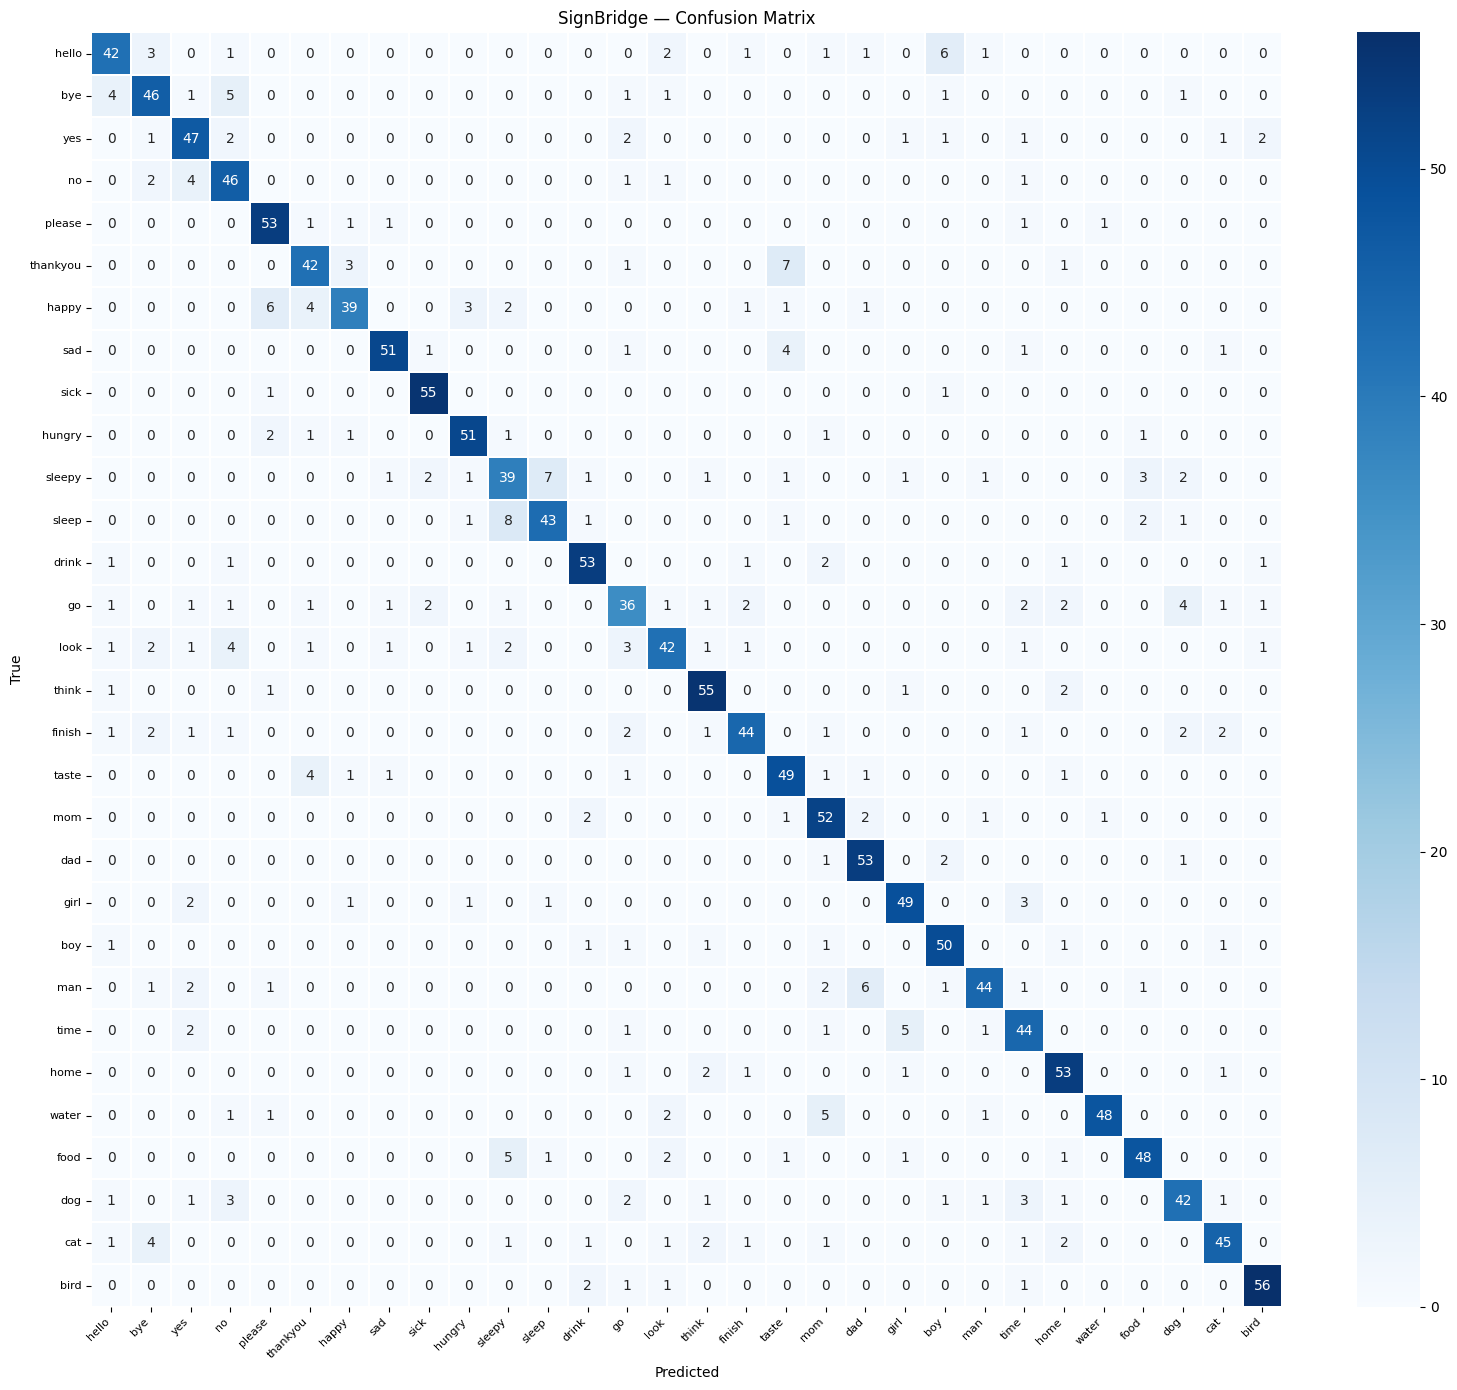

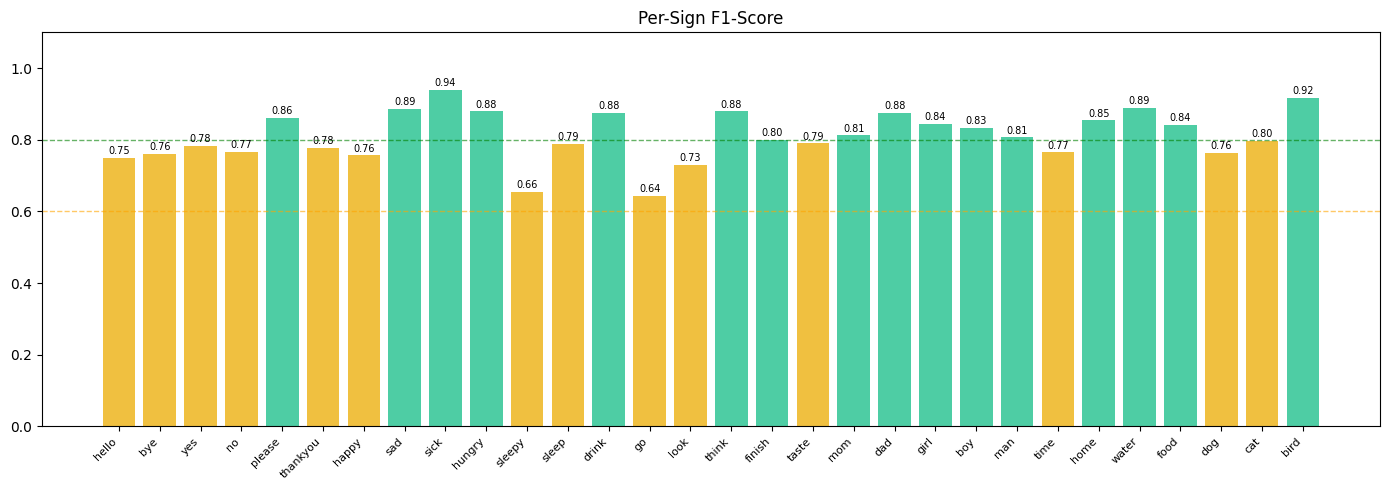

Done. Download confusion_matrix.png and f1_per_sign.png from Output tab.


In [17]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, classification_report,
    precision_score, recall_score, f1_score, accuracy_score
)

# Get predictions
y_pred_probs = model.predict(X_val, verbose=0)
y_pred       = np.argmax(y_pred_probs, axis=1)
y_true       = y_val

# Overall metrics
acc       = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average="weighted", zero_division=0)
recall    = recall_score(y_true, y_pred, average="weighted", zero_division=0)
f1        = f1_score(y_true, y_pred, average="weighted", zero_division=0)

print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")

# Per-class report
print("\n", classification_report(y_true, y_pred, target_names=SIGNS_30, zero_division=0))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=SIGNS_30, yticklabels=SIGNS_30,
            linewidths=0.3, ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("SignBridge — Confusion Matrix")
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

# F1 per sign bar chart
f1_scores = f1_score(y_true, y_pred, average=None, zero_division=0)
colors = ["#4ecda4" if s >= 0.80 else "#f0c040" if s >= 0.60 else "#e85d60" for s in f1_scores]
fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(SIGNS_30, f1_scores, color=colors)
ax.axhline(0.80, color="green", linestyle="--", linewidth=1, alpha=0.6)
ax.axhline(0.60, color="orange", linestyle="--", linewidth=1, alpha=0.6)
for bar, score in zip(bars, f1_scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{score:.2f}", ha="center", fontsize=7)
ax.set_title("Per-Sign F1-Score")
ax.set_ylim(0, 1.1)
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.tight_layout()
plt.savefig("f1_per_sign.png", dpi=150, bbox_inches="tight")
plt.show()

print("Done. Download confusion_matrix.png and f1_per_sign.png from Output tab.")

Metric            Value
------------------------------
TP                 1417
FP                  328
FN                  328
Precision         0.812
Recall            0.812
F1                0.812
------------------------------


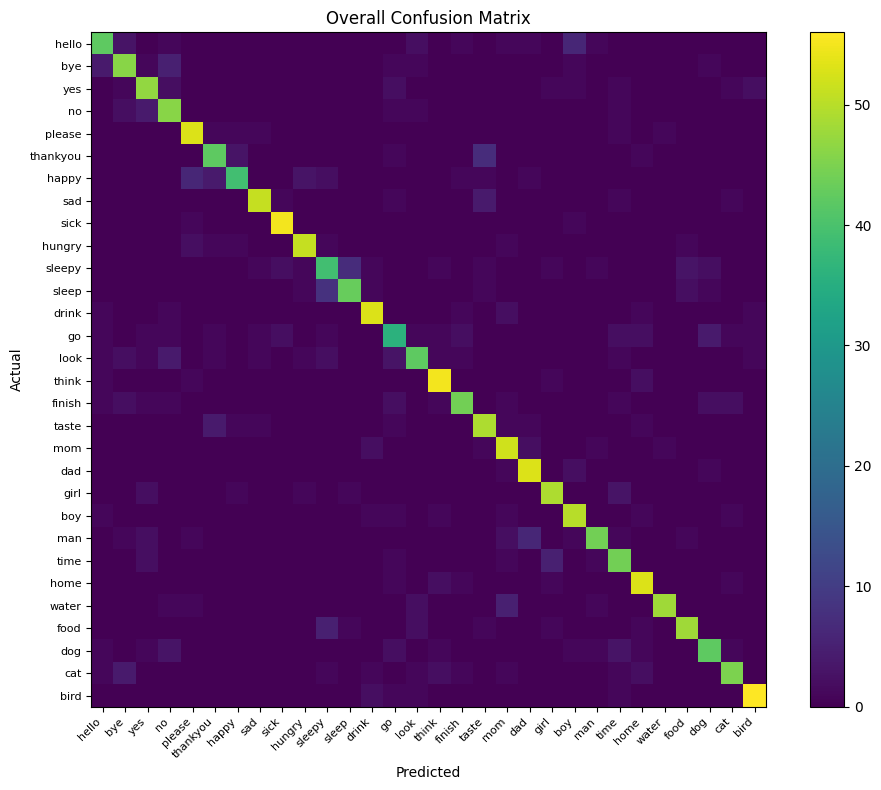

Saved: confusion_matrix.png


In [25]:
# ── Overall confusion matrix stats ────────────────────────────────
print(f"{'Metric':<12} {'Value':>10}")
print("-" * 30)

# Confusion matrix (multi-class)
num_classes = len(SIGNS_30)
cm = np.zeros((num_classes, num_classes), dtype=int)

# Fill confusion matrix manually
for t, p in zip(y_true, y_pred):
    cm[t][p] += 1

# ── Correct calculations (fixed) ─────────────────────────────────
TP_per_class = np.diag(cm)
FP_per_class = np.sum(cm, axis=0) - TP_per_class
FN_per_class = np.sum(cm, axis=1) - TP_per_class

# Micro totals (same variables as your format)
TP = int(np.sum(TP_per_class))
FP = int(np.sum(FP_per_class))
FN = int(np.sum(FN_per_class))

total = int(np.sum(cm))


# Metrics
prec = TP / (TP + FP) if (TP + FP) > 0 else 0.0
rec  = TP / (TP + FN) if (TP + FN) > 0 else 0.0
f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0

print(f"{'TP':<12} {TP:>10}")
print(f"{'FP':<12} {FP:>10}")
print(f"{'FN':<12} {FN:>10}")
print(f"{'Precision':<12} {prec:>10.3f}")
print(f"{'Recall':<12} {rec:>10.3f}")
print(f"{'F1':<12} {f1:>10.3f}")

print("-" * 30)


# ── Visual: Confusion matrix heatmap ──────────────────
fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(cm)

ax.set_xticks(np.arange(len(SIGNS_30)))
ax.set_yticks(np.arange(len(SIGNS_30)))
ax.set_xticklabels(SIGNS_30, rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(SIGNS_30, fontsize=8)

ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Overall Confusion Matrix")

plt.colorbar(im)
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

print("Saved: confusion_matrix.png")

In [19]:
# ── Per-sign TP, TN, FP, FN ──────────────────────────────────────────
print(f"{'Sign':<12} {'TP':>6} {'TN':>6} {'FP':>6} {'FN':>6} {'Precision':>10} {'Recall':>8} {'F1':>8}")
print("-" * 70)

tp_list, tn_list, fp_list, fn_list = [], [], [], []

for i, sign in enumerate(SIGNS_30):
    true_bin = (y_true == i).astype(int)
    pred_bin = (y_pred == i).astype(int)

    TP = int(np.sum((true_bin == 1) & (pred_bin == 1)))
    TN = int(np.sum((true_bin == 0) & (pred_bin == 0)))
    FP = int(np.sum((true_bin == 0) & (pred_bin == 1)))
    FN = int(np.sum((true_bin == 1) & (pred_bin == 0)))

    tp_list.append(TP)
    tn_list.append(TN)
    fp_list.append(FP)
    fn_list.append(FN)

    prec = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    rec  = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0

    print(f"{sign:<12} {TP:>6} {TN:>6} {FP:>6} {FN:>6} {prec:>10.3f} {rec:>8.3f} {f1:>8.3f}")

print("-" * 70)
print(f"{'TOTAL':<12} {sum(tp_list):>6} {sum(tn_list):>6} {sum(fp_list):>6} {sum(fn_list):>6}")

Sign             TP     TN     FP     FN  Precision   Recall       F1
----------------------------------------------------------------------
hello            42   1675     12     16      0.778    0.724    0.750
bye              46   1670     15     14      0.754    0.767    0.760
yes              47   1672     15     11      0.758    0.810    0.783
no               46   1671     19      9      0.708    0.836    0.767
please           53   1675     12      5      0.815    0.914    0.862
thankyou         42   1679     12     12      0.778    0.778    0.778
happy            39   1681      7     18      0.848    0.684    0.757
sad              51   1681      5      8      0.911    0.864    0.887
sick             55   1683      5      2      0.917    0.965    0.940
hungry           51   1680      7      7      0.879    0.879    0.879
sleepy           39   1665     20     21      0.661    0.650    0.655
sleep            43   1679      9     14      0.827    0.754    0.789
drink            53

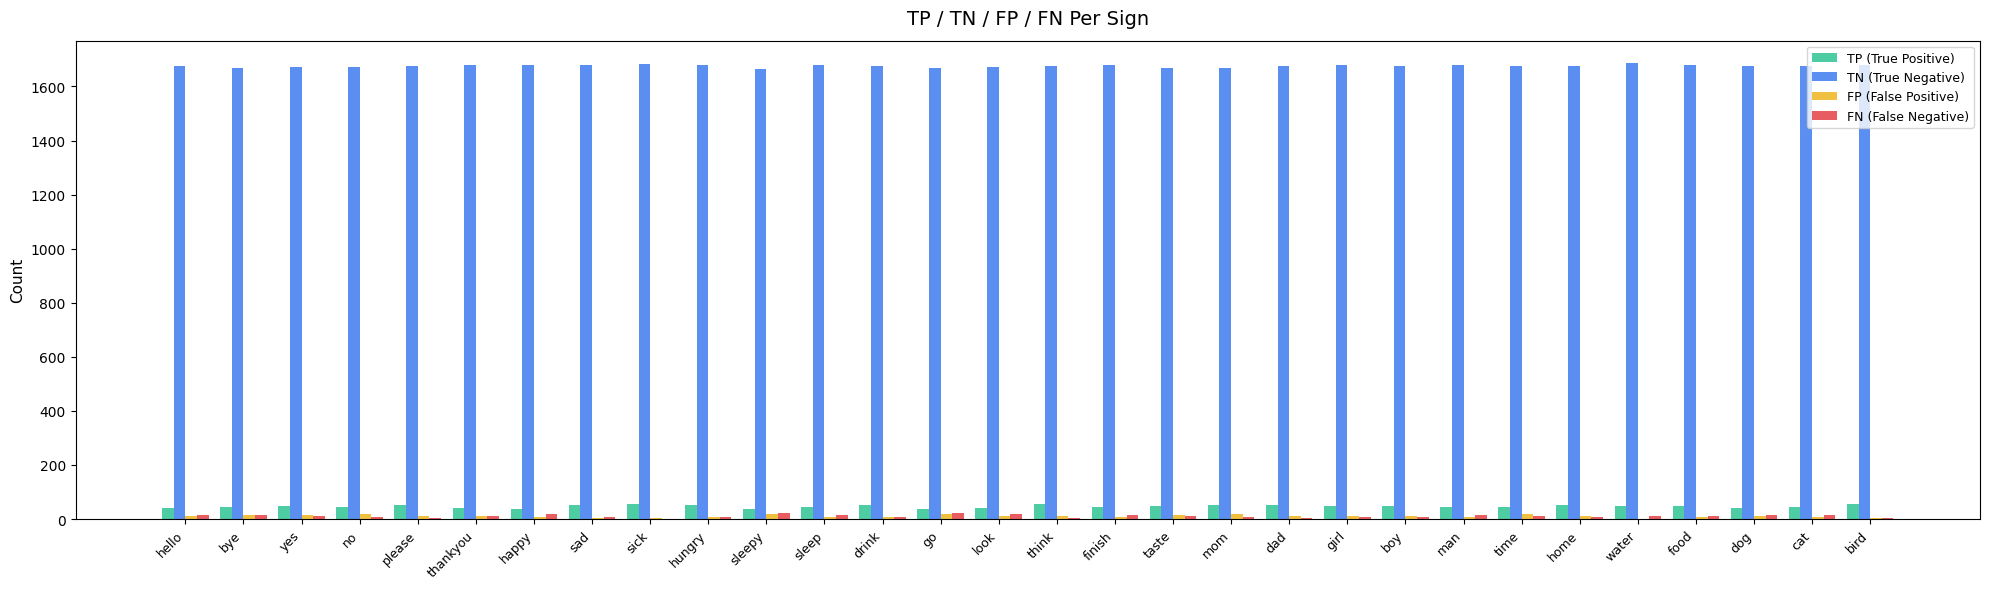

Saved: tp_tn_fp_fn_per_sign.png


In [20]:
# ── Grouped bar chart TP / TN / FP / FN per sign ─────────────────────
x     = np.arange(len(SIGNS_30))
width = 0.2

fig, ax = plt.subplots(figsize=(20, 6))

ax.bar(x - 1.5*width, tp_list, width, label="TP (True Positive)",  color="#4ecda4")
ax.bar(x - 0.5*width, tn_list, width, label="TN (True Negative)",  color="#5a8ef0")
ax.bar(x + 0.5*width, fp_list, width, label="FP (False Positive)", color="#f0c040")
ax.bar(x + 1.5*width, fn_list, width, label="FN (False Negative)", color="#e85d60")

ax.set_xticks(x)
ax.set_xticklabels(SIGNS_30, rotation=45, ha="right", fontsize=9)
ax.set_title("TP / TN / FP / FN Per Sign", fontsize=14, pad=12)
ax.set_ylabel("Count", fontsize=11)
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.savefig("tp_tn_fp_fn_per_sign.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: tp_tn_fp_fn_per_sign.png")